In [1]:
import numpy as np
import pandas as pd

In [2]:
es300 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/early_stop_300_results.tsv", sep="\t")
es300["early_stopping"] = [300 for i in range(len(es300))]

In [3]:
es500 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/early_stop_500_results.tsv", sep="\t")
es500["early_stopping"] = [500 for i in range(len(es500))]

In [4]:
es700 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/early_stop_700_results.tsv", sep="\t")
es700["early_stopping"] = [700 for i in range(len(es700))]

In [5]:
es1000 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/early_stop_1000_results.tsv", sep="\t")
es1000["early_stopping"] = [1000 for i in range(len(es1000))]

In [6]:
es1500 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/early_stop_1500_results.tsv", sep="\t")
es1500["early_stopping"] = [1500 for i in range(len(es1500))]

In [7]:
df = pd.concat([es300, es500, es700, es1000, es1500], ignore_index=True)

In [8]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [ ]:
df.columns

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

/tmp/SLURM_1103878/ipykernel_1479661/2877309192.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='early_stopping', y=metric, ax=ax, palette="Set2", order=es_order)
/tmp/SLURM_1103878/ipykernel_1479661/2877309192.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='early_stopping', y=metric, ax=ax, palette="Set2", order=es_order)
/tmp/SLURM_1103878/ipykernel_1479661/2877309192.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='early_stopping', y=metric, ax=ax, palette="Set2", order=es_order)
/tmp/SLURM

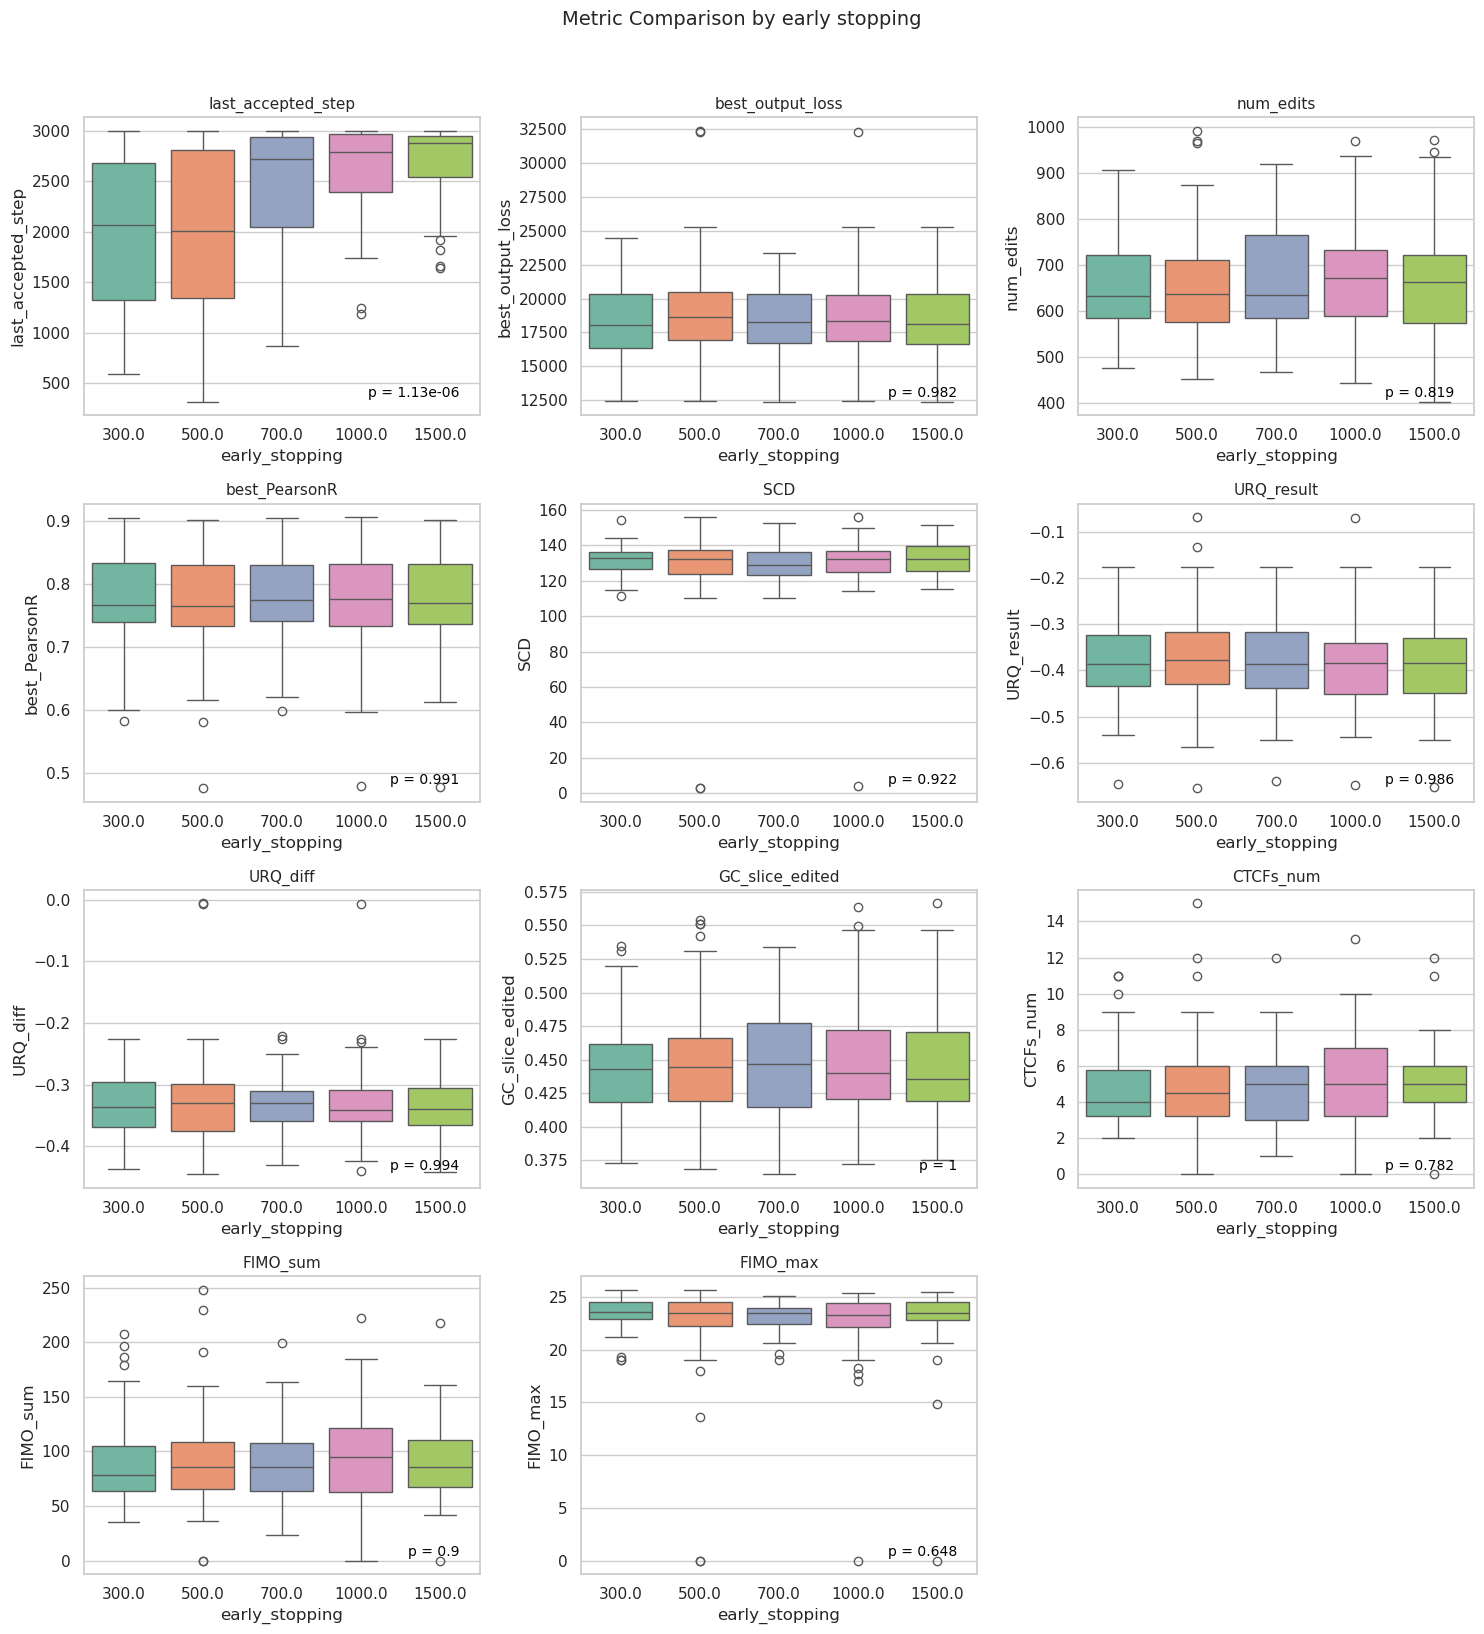

In [10]:
# Define metrics and tau order
metrics = [
    'last_accepted_step', 'best_output_loss', 'num_edits', 'best_PearsonR',
    'SCD', 'URQ_result', 'URQ_diff', 'GC_slice_edited',
    'CTCFs_num', 'FIMO_sum', 'FIMO_max'
]

# Optional: make sure tau is float
df['early_stopping'] = df['early_stopping'].astype(float)

# Sort tau values for consistent order in plots
es_order = sorted(df['early_stopping'].unique())

# Set up grid
n_cols = 3
n_rows = -(-len(metrics) // n_cols)

sns.set(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df, x='early_stopping', y=metric, ax=ax, palette="Set2", order=es_order)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("early_stopping")
    ax.set_ylabel(metric)

    # Kruskal-Wallis test across all tau groups
    try:
        groups = [df[df['early_stopping'] == es][metric].dropna() for es in es_order]
        if all(len(g) > 0 for g in groups):
            stat, pval = kruskal(*groups)
            ax.text(0.95, 0.05, f"p = {pval:.3g}", ha='right', va='bottom',
                    transform=ax.transAxes, fontsize=10, color='black')
        else:
            ax.text(0.95, 0.05, "p = N/A", ha='right', va='bottom',
                    transform=ax.transAxes, fontsize=10, color='gray')
    except ValueError:
        ax.text(0.95, 0.05, "p = N/A", ha='right', va='bottom',
                transform=ax.transAxes, fontsize=10, color='gray')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Metric Comparison by early stopping", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
